✅ Dataset chargé
    student_id  gender   age       filiere  year_of_study  attendance_rate  \
0  ENSPD000001    Male  21.0     Mecanique              5             85.8   
1  ENSPD000002  Female  17.0  Informatique              4             80.8   
2  ENSPD000003  Female  21.0   Energetique              4             85.5   
3  ENSPD000004  Female  24.0     Mecanique              2            100.0   
4  ENSPD000005    Male  23.0    GenieCivil              1             93.0   

   num_absences  assignments_avg  midterm_score  final_score  ...  \
0          14.0             78.6           85.5         80.6  ...   
1          19.0             85.1           82.6          5.7  ...   
2          14.0             60.4           61.6         72.8  ...   
3           0.0             47.2           60.4         67.2  ...   
4           7.0             47.3           65.2         26.3  ...   

   infra_usage_hours_month  supervisor_assigned  scholarship  \
0                     12.9         

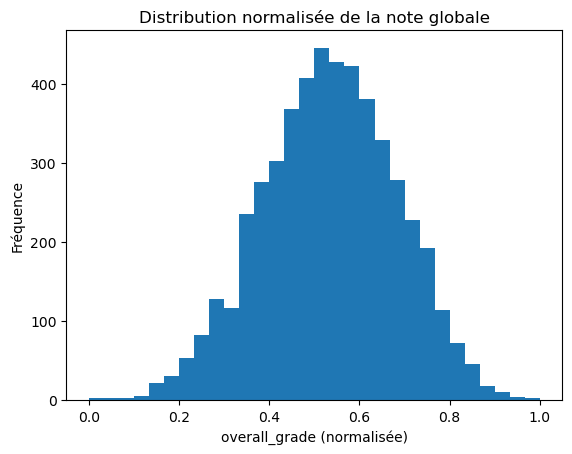

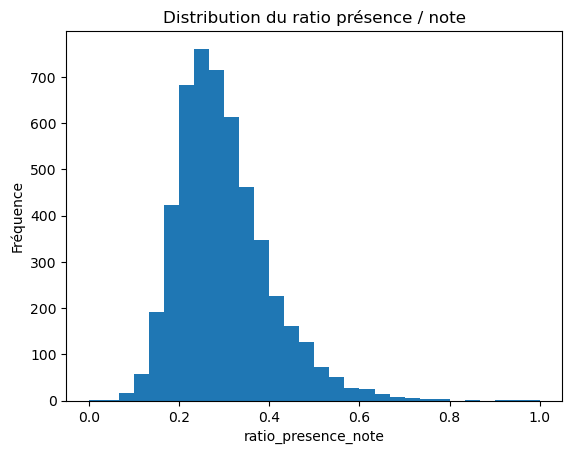

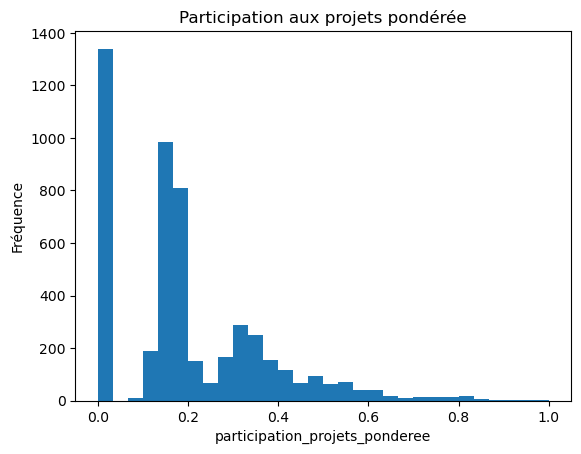

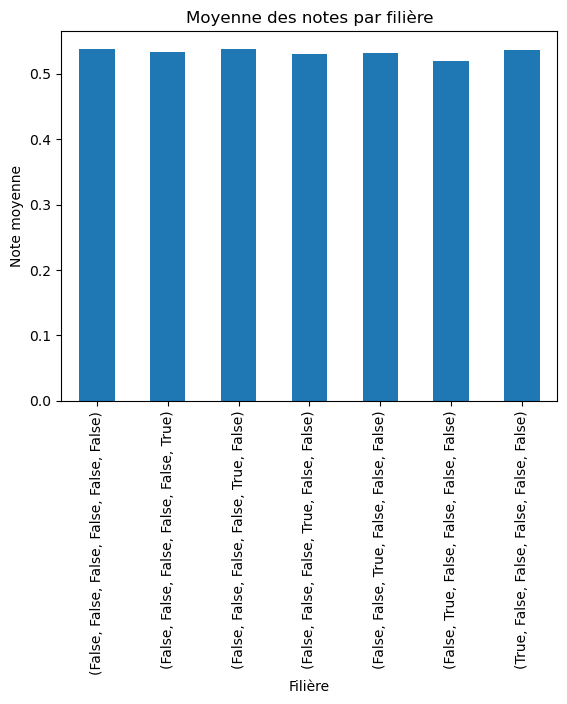


📁 Dataset final prêt pour ML sauvegardé : dataset_final_pret_ML.csv


In [2]:
# =========================================================
# JOUR 5 – FEATURE ENGINEERING
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# =========================================================
# 1️⃣ Chargement du dataset nettoyé
# =========================================================
df = pd.read_csv("ensp_dataset_5000_clean.csv")

print("✅ Dataset chargé")
print(df.head())

# =========================================================
# 2️⃣ CRÉATION DE NOUVELLES VARIABLES
# =========================================================

# 🔹 Ratio présence / note globale
df['ratio_presence_note'] = df['attendance_rate'] / (df['overall_grade'] + 1e-5)

# 🔹 Participation aux projets pondérée
# (on donne plus d’importance aux projets si l’étudiant est assidu)
df['participation_projets_ponderee'] = (
    df['project_participation'] * df['attendance_rate']
)

# 🔹 Moyenne par filière
df['moyenne_filiere'] = df.groupby('filiere')['overall_grade'].transform('mean')

print("\n📊 Nouvelles variables créées :")
print(df[['ratio_presence_note',
          'participation_projets_ponderee',
          'moyenne_filiere']].head())

# =========================================================
# 3️⃣ ENCODAGE DES VARIABLES CATÉGORIELLES
# =========================================================

# 🔹 Label Encoding (pour modèles simples)
label_cols = ['gender', 'scholarship', 'lab_access', 'supervisor_assigned']

le = LabelEncoder()
for col in label_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])

# 🔹 One-Hot Encoding (pour filière)
df = pd.get_dummies(df, columns=['filiere'], drop_first=True)

print("\n✅ Encodage terminé")

# =========================================================
# 4️⃣ NORMALISATION DES VARIABLES NUMÉRIQUES
# =========================================================

num_cols = [
    'attendance_rate',
    'assignments_avg',
    'midterm_score',
    'final_score',
    'overall_grade',
    'ratio_presence_note',
    'participation_projets_ponderee'
]

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("\n✅ Normalisation Min-Max appliquée")

# =========================================================
# 5️⃣ VISUALISATIONS POUR ANALYSE
# =========================================================

# 🔹 Distribution avant/après normalisation (overall_grade)
plt.figure()
plt.hist(df['overall_grade'], bins=30)
plt.title("Distribution normalisée de la note globale")
plt.xlabel("overall_grade (normalisée)")
plt.ylabel("Fréquence")
plt.show()

# 🔹 Ratio présence / note
plt.figure()
plt.hist(df['ratio_presence_note'], bins=30)
plt.title("Distribution du ratio présence / note")
plt.xlabel("ratio_presence_note")
plt.ylabel("Fréquence")
plt.show()

# 🔹 Participation aux projets pondérée
plt.figure()
plt.hist(df['participation_projets_ponderee'], bins=30)
plt.title("Participation aux projets pondérée")
plt.xlabel("participation_projets_ponderee")
plt.ylabel("Fréquence")
plt.show()

# 🔹 Moyenne des notes par filière
moyennes = df.groupby(
    [col for col in df.columns if col.startswith('filiere_')]
)['overall_grade'].mean()

plt.figure()
moyennes.plot(kind='bar')
plt.title("Moyenne des notes par filière")
plt.xlabel("Filière")
plt.ylabel("Note moyenne")
plt.show()

# =========================================================
# 6️⃣ SAUVEGARDE DU DATASET FINAL
# =========================================================

df.to_csv("dataset_final_pret_ML.csv", index=False)
print("\n📁 Dataset final prêt pour ML sauvegardé : dataset_final_pret_ML.csv")



📊 ANALYSE UNIVARIÉE

--- overall_grade ---
Moyenne : 0.533
Médiane : 0.535
Écart-type : 0.148


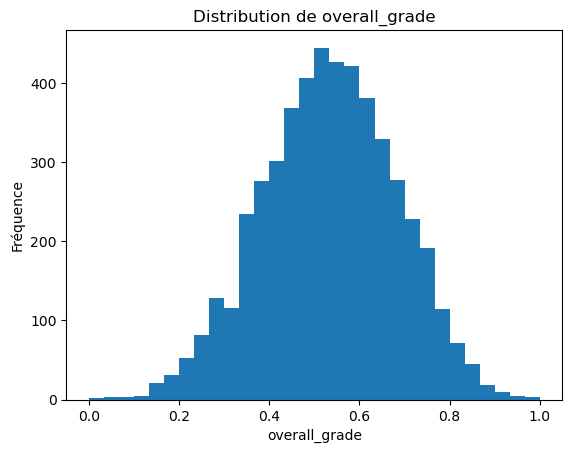


--- attendance_rate ---
Moyenne : 0.717
Médiane : 0.723
Écart-type : 0.173


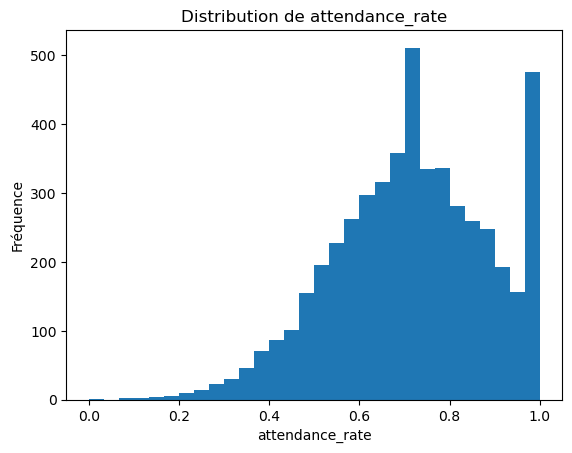


--- project_participation ---
Moyenne : 1.186
Médiane : 1.000
Écart-type : 1.034


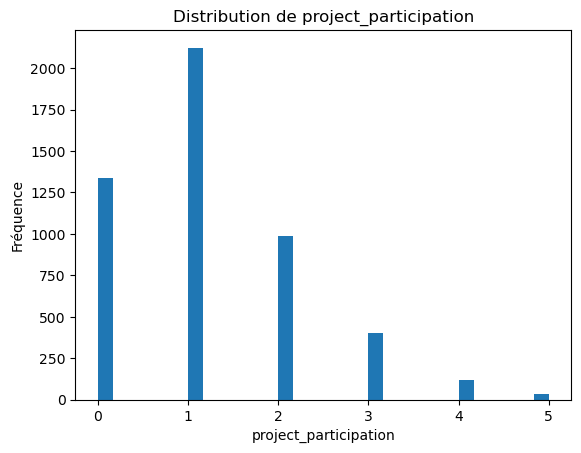

In [3]:
import numpy as np

# Colonnes clés
cols_uni = [
    'overall_grade',
    'attendance_rate',
    'project_participation'
]

print("\n📊 ANALYSE UNIVARIÉE")
for col in cols_uni:
    print(f"\n--- {col} ---")
    print(f"Moyenne : {df[col].mean():.3f}")
    print(f"Médiane : {df[col].median():.3f}")
    print(f"Écart-type : {df[col].std():.3f}")

    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()


In [5]:
print("\n📈 CORRÉLATIONS BIVARIÉES")

corr_presence_note = df['attendance_rate'].corr(df['overall_grade'])
corr_projet_reussite = df['project_participation'].corr(df['passed'])

print(f"Corrélation présence ↔ moyenne générale : r = {corr_presence_note:.3f}")
print(f"Corrélation projets ↔ réussite : r = {corr_projet_reussite:.3f}")



📈 CORRÉLATIONS BIVARIÉES
Corrélation présence ↔ moyenne générale : r = 0.102
Corrélation projets ↔ réussite : r = 0.003


In [7]:
reussite = df[df['passed'] == 1]['overall_grade']
echec = df[df['passed'] == 0]['overall_grade']

print("\n🎓 COMPARAISON DES MOYENNES")
print(f"Moyenne étudiants réussis : {reussite.mean():.2f}")
print(f"Moyenne étudiants échoués : {echec.mean():.2f}")



🎓 COMPARAISON DES MOYENNES
Moyenne étudiants réussis : 0.57
Moyenne étudiants échoués : 0.31


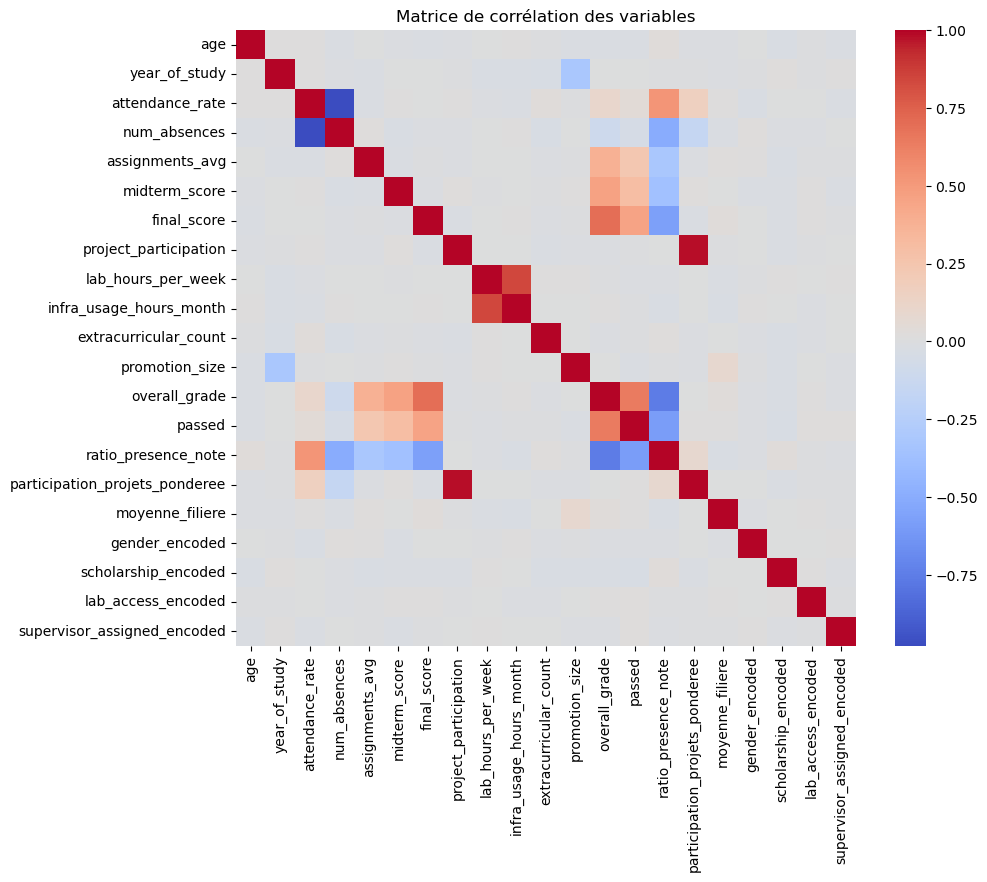

In [8]:
import seaborn as sns

plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Matrice de corrélation des variables")
plt.show()


In [10]:
print("\n🏫 ANALYSE PAR FILIÈRE")

filiere_cols = [col for col in df.columns if col.startswith('filiere_')]

for col in filiere_cols:
    taux = df[df[col] == 1]['passed'].mean() * 100
    print(f"{col.replace('filiere_', '')} : {taux:.2f}% de réussite")



🏫 ANALYSE PAR FILIÈRE
Electrique : 84.20% de réussite
Energetique : 84.24% de réussite
GenieCivil : 85.54% de réussite
Informatique : 84.32% de réussite
Mecanique : 86.27% de réussite
Telecom : 83.79% de réussite


In [12]:
presence_elevee = df[df['attendance_rate'] > 0.8]
taux_reussite = presence_elevee['passed'].mean() * 100

print(f"\n🎯 Taux de réussite si présence > 80% : {taux_reussite:.2f}%")



🎯 Taux de réussite si présence > 80% : 86.17%
